# Linear Regression Used
### Evaluating trends and sales estimates
### Analysing the impact of price changes
### Assessment of risk in financial services and insurance domain

In [ ]:
## What is R-Square?
### R-squared value is a statistical measure of how close the data are to the fitted regression line.
### It is also known as the coefficient of determination, or th coefficient of multiple determination.

In [ ]:
# Importing Python libraries
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = (20.0, 10.0)

In [ ]:
# Reading data
data = pd.read_csv("headbrain.csv")
print(data.shape)
data.head()

(237, 4)


,Gender,Age Range,Head Size(cm^3),Brain Weight(grams)
0,1,1,4512,1530
1,1,1,3738,1297
2,1,1,4261,1335
3,1,1,3777,1282
4,1,1,4177,1590


In [ ]:
# Collecting X and y
X = data['Head Size(cm^3)'].values
Y = data['Brain Weight(grams)'].values

In [ ]:
# Mean X and y
mean_x = np.mean(X) # calculate the mean (average of X)
mean_y = np.mean(Y) # calculate the mean (average o Y)

# Total number of values
m = len(X) # get the total number of data points

# Using the formula to calculate b1 and b2
numer = 0 # numerator
denom = 0 # denominator
for i in range(m):
    numer +=(X[i] - mean_x) * (Y[i] - mean_y) # the sum of products of deviations from means
    denom +=(X[i] - mean_x) ** 2 # the sum of squared deviations of x from its mean
b1 = numer / denom  # calculate the slope coefficient using the least squares formula
b0 = mean_y - (b1 * mean_x) # calculate y-intercept coefficent

# Print coefficients
print(b1, b0) # display the calculated slope and intercept value

0.26342933948939945 325.57342104944223


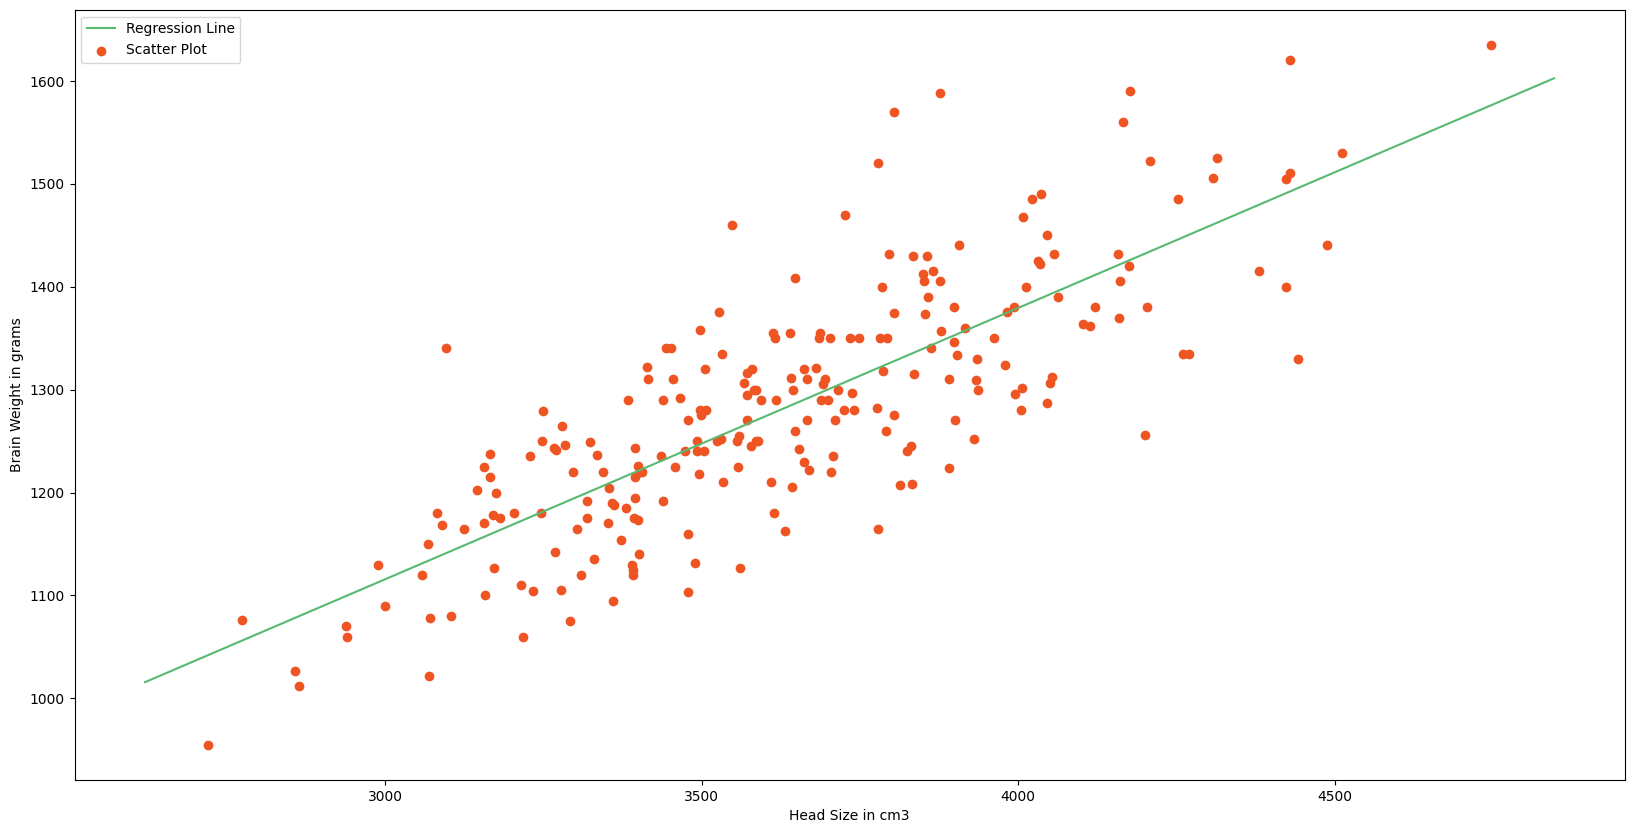

In [ ]:
# Plotting values and regression line
max_x = np.max(X) + 100 
min_x = np.min(X) - 100

# Calculating line values x and y
x = np.linspace(min_x, max_x, 1000)
y = b0 + b1 * x # calculate the y-values for the regression line using the linear equation

# Plotting line
plt.plot(x, y, color ='#58b970', label ='Regression Line')

# Plotting scatter points
plt.scatter(X, Y, c='#ef5423', label = 'Scatter Plot')

plt.xlabel('Head Size in cm3')
plt.ylabel('Brain Weight in grams')
plt.legend()
plt.show()

In [ ]:
# Calculating R-Squared (Coefficient of Determination) for Linear Regression Model
ss_t = 0 # total sum of squares
ss_r = 0 # residual sum of squares
for i in range(m):
    y_pred = b0 + b1 * X[i] # calculate the predicted y-values using the linear regression equation
    ss_t += (Y[i] - mean_y) ** 2
    ss_r += (Y[i] - y_pred) ** 2
r2 = 1 - (ss_r/ss_t) # calculate R-Squared
print(r2)

0.6393117199570003


In [ ]:
# Machine learning using sklearn
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# Reshape data
X = X.reshape((m, 1)) # covert X from a 1D array to a 2D array with M rows and 1 column

# Create and train model
reg = LinearRegression()
reg.fit(X, Y) # train the model using the input features X and target values Y 

#  Make predictions
Y_pred = reg.predict(X)

# Evaluate model
r2_score = reg.score(X, Y)

print(r2_score)

0.639311719957
